<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day11_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 11 Lab: Random Forests

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import validation_curve
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.metrics import classification_report


In [2]:
file_link = 'https://drive.google.com/uc?export=download&id=1_EHeUYiwejkcKICmLfm49XdK8Y9VBSzt'

# uhoh, semicolons
df = pd.read_csv(file_link, sep=';')

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


1. Ordinal encode education
2. Encode the boolean columns default and y to be 0 and 1.

In [3]:
df['education'].value_counts()

,count
education,
secondary,2306
tertiary,1350
primary,678
unknown,187


In [4]:
ord_map = {
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}
df['education'] = df['education'].map(ord_map)
df = df[df['education'] != 'unknown']

In [5]:
df['education'].value_counts()

,count
education,
2.0,2306
3.0,1350
1.0,678


Encode the boolean columns default and y to be 0 and 1.

In [6]:
# v1: one-hot encode and only keep one of the columns
# df = pd.get_dummies(df, columns=['default', 'y'], drop_first=True, dtype=float)

# v2: ordinal encode
ord_map = {
    'no': 0,
    'yes': 1
}
df['default'] = df['default'].map(ord_map)
df['y'] = df['y'].map(ord_map)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,1.0,0,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,0
1,33,services,married,2.0,0,4789,yes,yes,cellular,11,may,220,1,339,4,failure,0
2,35,management,single,3.0,0,1350,yes,no,cellular,16,apr,185,1,330,1,failure,0
3,30,management,married,3.0,0,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,2.0,0,0,yes,no,unknown,5,may,226,1,-1,0,unknown,0


In [7]:
y = df['y']
X = df[['age', 'education', 'default', 'balance', 'previous']]

In [8]:
X

,age,education,default,balance,previous
0,30,1.0,0,1787,0
1,33,2.0,0,4789,4
2,35,3.0,0,1350,1
3,30,3.0,0,1476,0
4,59,2.0,0,0,0
...,...,...,...,...,...
4516,33,2.0,0,-333,0
4517,57,3.0,1,-3313,0
4518,57,2.0,0,295,0
4519,28,2.0,0,1137,3


Divide the data into randomized training and test partitions. Use 50% of the data
as the test set, keeping 50% for training.


In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.5, random_state=13)

Train a RandomForestClassifier with n_estimators=1, max_depth=300, min_samples_leaf=1. (This specifies a forest with one estimator, or tree, which is the same as a basic decision tree.)


In [10]:
model = RandomForestClassifier(n_estimators=1, max_depth=300, min_samples_leaf=1)
model.fit(Xtrain, ytrain)

RandomForestClassifier(max_depth=300, n_estimators=1)

Predict the test data to get a baseline accuracy that we’ll try to improve by finding better hyperparameters.

In [11]:
ypred = model.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
accuracy


0.7908005307386112

## Create validation curves with 3-fold cross validation to find the best hyperparameters for the random forest model. Search over a range of values for n_estimators, max_depth, and min_samples_leaf. It may be helpful to search coarser ranges to start and then narrow down the best ranges (for speed).


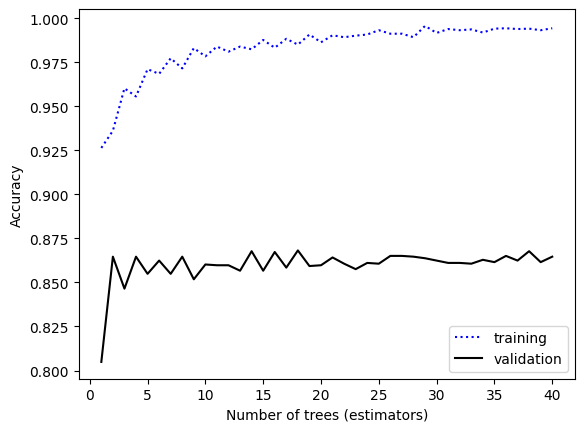

In [12]:
# Make an array to hold the values to try
trees = np.arange(1, 41) # np.arange(1, 200, 20)

train_scores, valid_scores = validation_curve(
    RandomForestClassifier(), Xtrain, ytrain,
    param_name="n_estimators", param_range=trees, cv=3)

plt.plot(trees, train_scores.mean(axis=1), ':b', label='training')
plt.plot(trees, valid_scores.mean(axis=1), 'k', label='validation')
plt.legend()
plt.xlabel('Number of trees (estimators)')
plt.ylabel('Accuracy');

## max_depth

Text(0, 0.5, 'Accuracy')

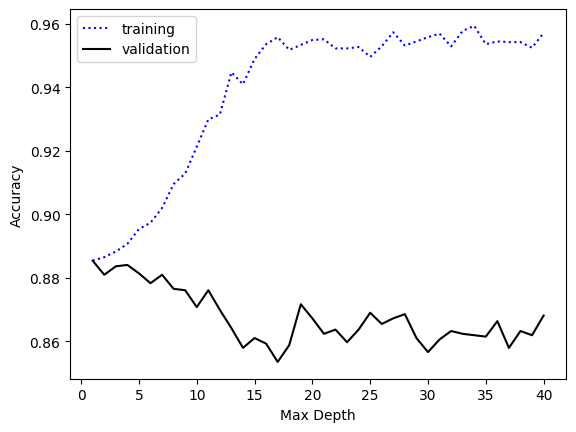

In [13]:
# Make an array to hold the values to try
vals = np.arange(0, 41) # np.arange(1, 200, 20)

train_scores, valid_scores = validation_curve(
    RandomForestClassifier(n_estimators=4), Xtrain, ytrain,
    param_name="max_depth", param_range=vals, cv=3)

plt.plot(vals, train_scores.mean(axis=1), ':b', label='training')
plt.plot(vals, valid_scores.mean(axis=1), 'k', label='validation')
plt.legend()
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')


## min_samples_leaf

Text(0, 0.5, 'Accuracy')

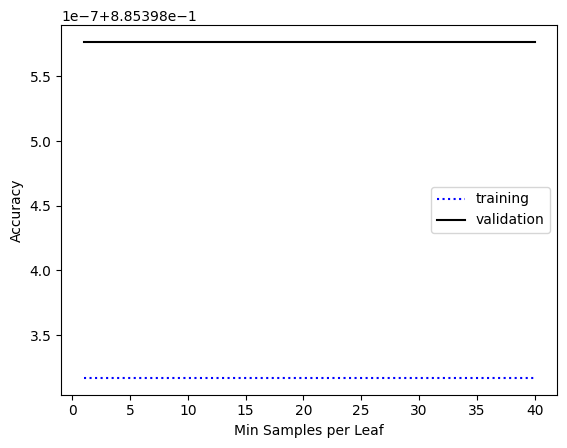

In [14]:
# Make an array to hold the values to try
vals = np.arange(1, 41, 3) # np.arange(1, 200, 20)

train_scores, valid_scores = validation_curve(
    RandomForestClassifier(n_estimators=4, max_depth=1), Xtrain, ytrain,
    param_name="min_samples_leaf", param_range=vals, cv=3)

plt.plot(vals, train_scores.mean(axis=1), ':b', label='training')
plt.plot(vals, valid_scores.mean(axis=1), 'k', label='validation')
plt.legend()
plt.xlabel('Min Samples per Leaf')
plt.ylabel('Accuracy')


## Train a model with the best hyperparameters based on the 3 validation curves.
Use your trained model to predict the labels for the test set.


In [15]:
model = RandomForestClassifier(n_estimators=4, max_depth=1, min_samples_leaf=4, random_state=0)
model.fit(Xtrain, ytrain)

ypred = model.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
accuracy

0.8841220698805838

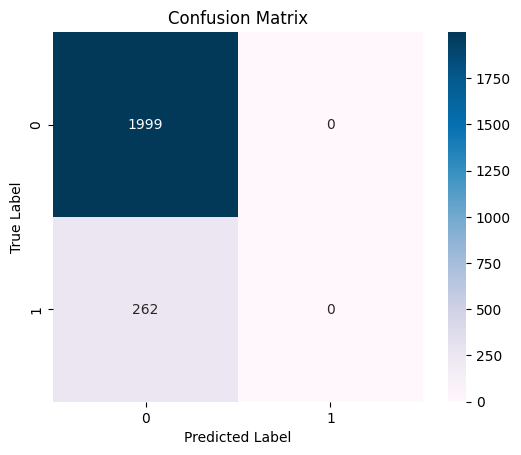

In [16]:
# Note that is doesn't matter what order the classes are in, as long as
# we're consistent between the call to confusion_matrix and heatmap
classes = ytrain.unique()
cm = confusion_matrix(ytest, ypred, labels=classes)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap="PuBu",
                    xticklabels=classes,
                    yticklabels=classes)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [17]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1999
           1       0.00      0.00      0.00       262

    accuracy                           0.88      2261
   macro avg       0.44      0.50      0.47      2261
weighted avg       0.78      0.88      0.83      2261



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Show a bar graph for the feature importance discovered by the model.

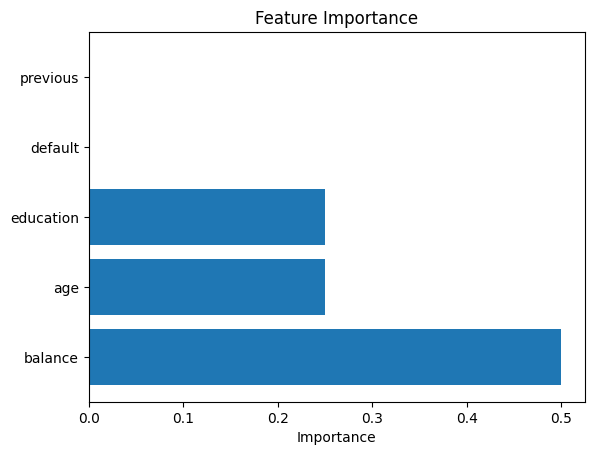

In [18]:
# Feature Importance

# Make a DataFrame for ease of sorting and visualization
feat_imp = pd.DataFrame({'Feature': model.feature_names_in_,
                      'Importance': model.feature_importances_})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# horizontal bar charts can make text easier to read
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance');


## Visualize the first decision tree in the forest

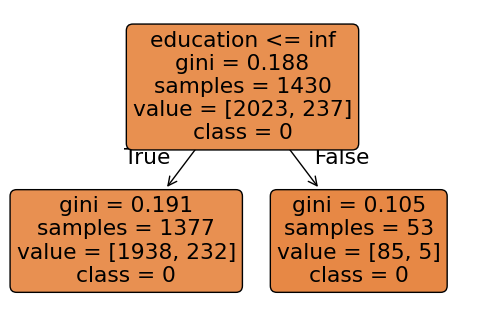

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
first_tree = model.estimators_[0]
tree.plot_tree(first_tree, feature_names=model.feature_names_in_,
               max_depth=5,
               class_names=model.classes_.astype(str),
               rounded=True, filled=True, ax=ax);

## Visualizing the class label counts

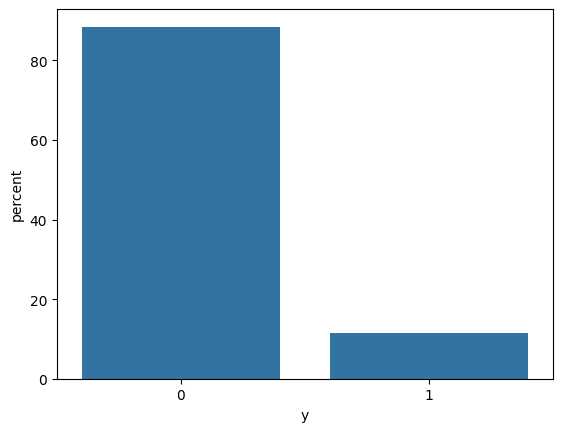

In [20]:
# v1: pandas
# counts = y.value_counts()
# total = counts.sum()
# percents = 100 * counts / total
# percents.plot(kind='bar')
# plt.ylabel('Percentage')
# plt.xlabel('Class Label')
# plt.show()

# v2: seaborn
sns.countplot(data=df, x=y, stat='percent');